In [1]:
# Upload file CSV dari komputer kamu
from google.colab import files
uploaded = files.upload()

Saving smart_farming_sensor_data.csv to smart_farming_sensor_data.csv


In [2]:
# Import library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('smart_farming_sensor_data.csv')

# Lihat 5 baris pertama
print("=== 5 Baris Pertama Dataset ===")
print(df.head())

# Lihat ukuran dataset
print(f"\n=== Ukuran Dataset ===")
print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")

=== 5 Baris Pertama Dataset ===
    farm_id       region crop_type  soil_moisture_%  soil_pH  temperature_C  \
0  FARM0001  North India     Wheat            35.95     5.99          17.79   
1  FARM0002    South USA   Soybean            19.74     7.24          30.18   
2  FARM0003    South USA     Wheat            29.32     7.16          27.37   
3  FARM0004  Central USA     Maize            17.33     6.03          33.73   
4  FARM0005  Central USA    Cotton            19.37     5.92          33.86   

   rainfall_mm  humidity_%  sunlight_hours irrigation_type  ... sowing_date  \
0        75.62       77.03            7.27             NaN  ...  2024-01-08   
1        89.91       61.13            5.67       Sprinkler  ...  2024-02-04   
2       265.43       68.87            8.23            Drip  ...  2024-02-03   
3       212.01       70.46            5.03       Sprinkler  ...  2024-02-21   
4       269.09       55.73            7.93             NaN  ...  2024-02-05   

   harvest_date to

In [3]:
# Informasi tipe data tiap kolom
print("=== Info Dataset ===")
print(df.info())

# Statistik dasar (mean, min, max, dll)
print("\n=== Statistik Dasar ===")
print(df.describe())

# Cek missing values
print("\n=== Missing Values ===")
print(df.isnull().sum())

=== Info Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   farm_id               500 non-null    object 
 1   region                500 non-null    object 
 2   crop_type             500 non-null    object 
 3   soil_moisture_%       500 non-null    float64
 4   soil_pH               500 non-null    float64
 5   temperature_C         500 non-null    float64
 6   rainfall_mm           500 non-null    float64
 7   humidity_%            500 non-null    float64
 8   sunlight_hours        500 non-null    float64
 9   irrigation_type       350 non-null    object 
 10  fertilizer_type       500 non-null    object 
 11  pesticide_usage_ml    500 non-null    float64
 12  sowing_date           500 non-null    object 
 13  harvest_date          500 non-null    object 
 14  total_days            500 non-null    int64  
 15  yi

In [4]:
# ============================================
# DATA CLEANING
# ============================================

# 1. Isi missing values
# irrigation_type & crop_disease_status diisi dengan "Unknown"
df['irrigation_type'] = df['irrigation_type'].fillna('Unknown')
df['crop_disease_status'] = df['crop_disease_status'].fillna('Unknown')

# 2. Konversi kolom tanggal ke format datetime
df['sowing_date'] = pd.to_datetime(df['sowing_date'])
df['harvest_date'] = pd.to_datetime(df['harvest_date'])
df['timestamp'] = pd.to_datetime(df['timestamp'])

# 3. Cek duplikat
print(f"Jumlah data duplikat: {df.duplicated().sum()}")

# 4. Cek hasil cleaning
print("\n=== Missing Values Setelah Cleaning ===")
print(df.isnull().sum())

print("\n=== Data Quality Score ===")
total = df.shape[0] * df.shape[1]
missing = df.isnull().sum().sum()
accuracy = round(1 - (missing / total), 4)
completeness = round(df.notnull().sum().sum() / total, 4)

# Timeliness: % data dalam 30 hari terakhir dari timestamp terbaru
latest = df['timestamp'].max()
recent = df[df['timestamp'] >= latest - pd.Timedelta(days=30)].shape[0]
timeliness = round(recent / df.shape[0], 4)

print(f"Accuracy     : {accuracy * 100}%")
print(f"Completeness : {completeness * 100}%")
print(f"Timeliness   : {timeliness * 100}%")

Jumlah data duplikat: 0

=== Missing Values Setelah Cleaning ===
farm_id                 0
region                  0
crop_type               0
soil_moisture_%         0
soil_pH                 0
temperature_C           0
rainfall_mm             0
humidity_%              0
sunlight_hours          0
irrigation_type         0
fertilizer_type         0
pesticide_usage_ml      0
sowing_date             0
harvest_date            0
total_days              0
yield_kg_per_hectare    0
sensor_id               0
timestamp               0
latitude                0
longitude               0
NDVI_index              0
crop_disease_status     0
dtype: int64

=== Data Quality Score ===
Accuracy     : 100.0%
Completeness : 100.0%
Timeliness   : 1.4000000000000001%


In [5]:
# Simpan hasil cleaning
df.to_csv('cleaned_data.csv', index=False)
print("✅ cleaned_data.csv berhasil disimpan!")

✅ cleaned_data.csv berhasil disimpan!


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/tmp/ipykernel_1358/3939125581.py:62: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1358/3939125581.py:62: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1358/3939125581.py:63: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig('dashboard_screenshot.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_1358/3939125581.py:63: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from font(s) DejaVu Sans.
  plt.savefig('dashboard_screenshot.png', dpi=150, bbox_inches='tight

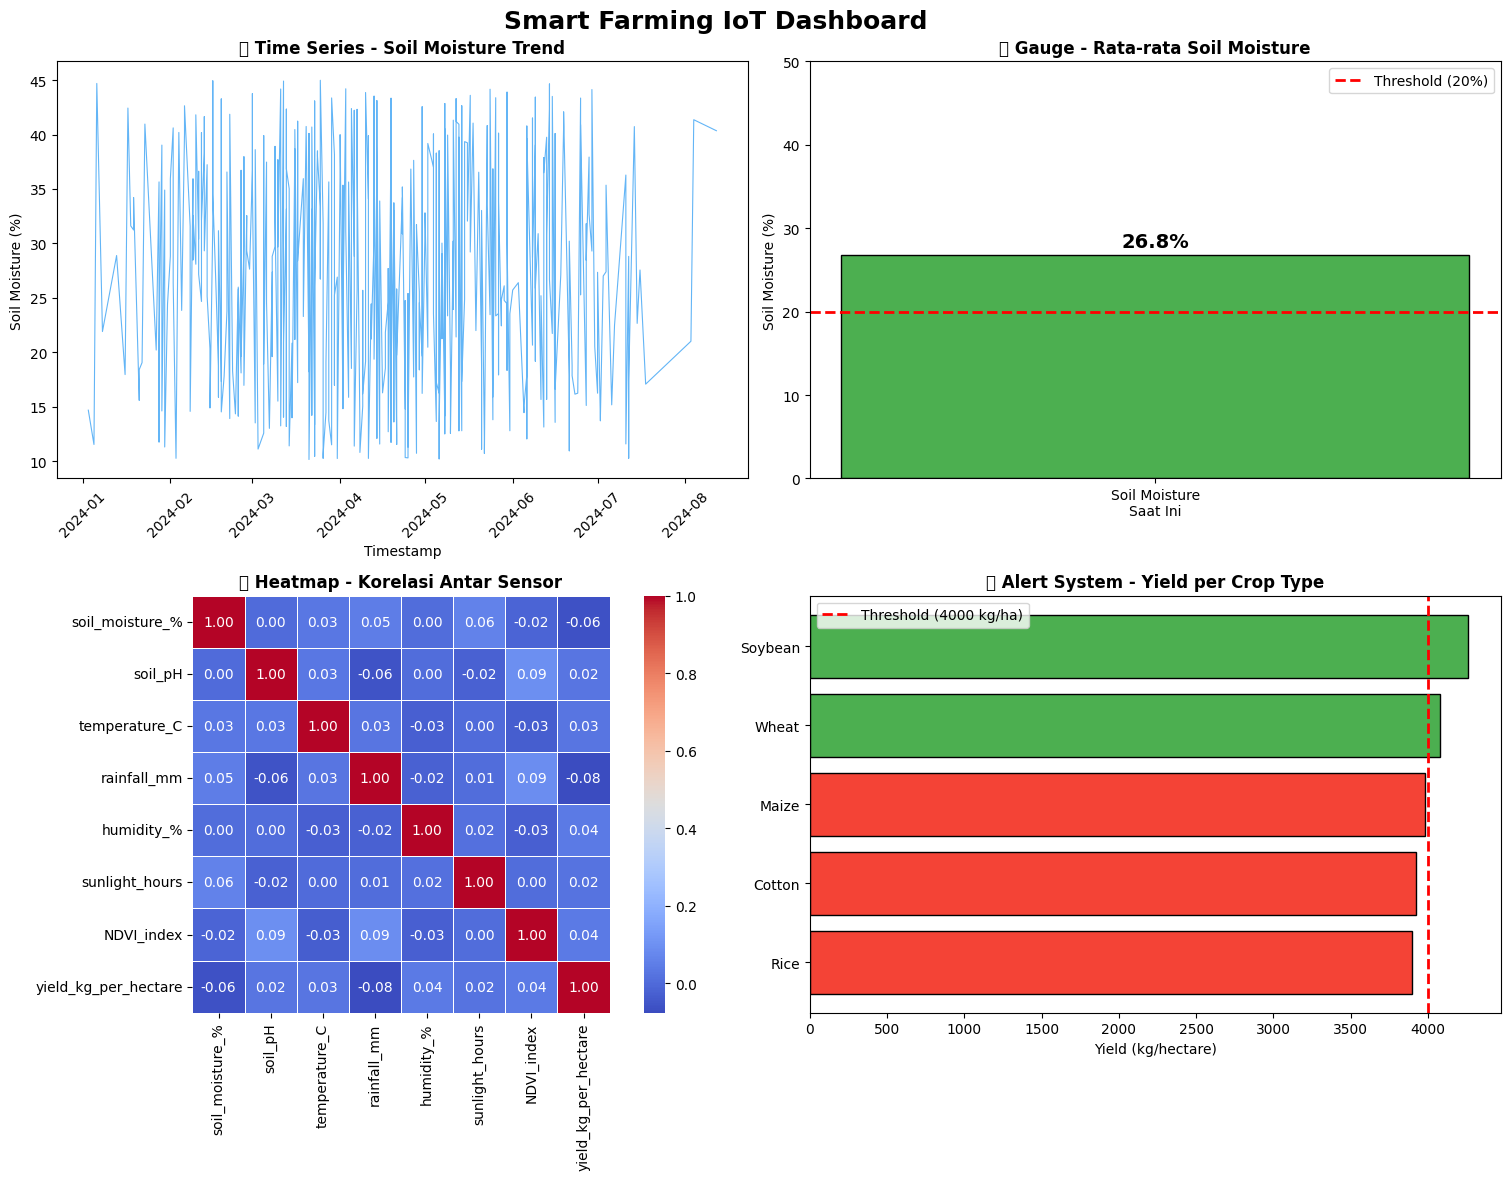

✅ Dashboard berhasil disimpan!


In [6]:
# ============================================
# VISUALIZATION - 4 CHART WAJIB
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Smart Farming IoT Dashboard', fontsize=18, fontweight='bold')

# ----------------------------------------
# CHART 1: Time Series - Tren Soil Moisture
# ----------------------------------------
df_sorted = df.sort_values('timestamp')
axes[0,0].plot(df_sorted['timestamp'], df_sorted['soil_moisture_%'],
               color='#2196F3', linewidth=0.8, alpha=0.7)
axes[0,0].set_title('📈 Time Series - Soil Moisture Trend', fontweight='bold')
axes[0,0].set_xlabel('Timestamp')
axes[0,0].set_ylabel('Soil Moisture (%)')
axes[0,0].tick_params(axis='x', rotation=45)

# ----------------------------------------
# CHART 2: Gauge Meter - Rata-rata Soil Moisture
# ----------------------------------------
avg_moisture = df['soil_moisture_%'].mean()
threshold = 20  # batas minimum

colors = ['#4CAF50' if avg_moisture >= threshold else '#F44336']
bars = axes[0,1].bar(['Soil Moisture\nSaat Ini'], [avg_moisture],
                      color=colors, width=0.4, edgecolor='black')
axes[0,1].axhline(y=threshold, color='red', linestyle='--',
                   linewidth=2, label=f'Threshold ({threshold}%)')
axes[0,1].set_ylim(0, 50)
axes[0,1].set_title('🌡️ Gauge - Rata-rata Soil Moisture', fontweight='bold')
axes[0,1].set_ylabel('Soil Moisture (%)')
axes[0,1].legend()
axes[0,1].text(0, avg_moisture + 1, f'{avg_moisture:.1f}%',
               ha='center', fontsize=14, fontweight='bold')

# ----------------------------------------
# CHART 3: Heatmap - Korelasi Antar Sensor
# ----------------------------------------
sensor_cols = ['soil_moisture_%', 'soil_pH', 'temperature_C',
               'rainfall_mm', 'humidity_%', 'sunlight_hours',
               'NDVI_index', 'yield_kg_per_hectare']
corr_matrix = df[sensor_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[1,0], square=True, linewidths=0.5)
axes[1,0].set_title('🔥 Heatmap - Korelasi Antar Sensor', fontweight='bold')

# ----------------------------------------
# CHART 4: Alert System - Yield per Crop Type
# ----------------------------------------
avg_yield = df.groupby('crop_type')['yield_kg_per_hectare'].mean().sort_values()
yield_threshold = 4000
bar_colors = ['#F44336' if y < yield_threshold else '#4CAF50'
              for y in avg_yield.values]
axes[1,1].barh(avg_yield.index, avg_yield.values, color=bar_colors, edgecolor='black')
axes[1,1].axvline(x=yield_threshold, color='red', linestyle='--',
                   linewidth=2, label=f'Threshold ({yield_threshold} kg/ha)')
axes[1,1].set_title('🚨 Alert System - Yield per Crop Type', fontweight='bold')
axes[1,1].set_xlabel('Yield (kg/hectare)')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('dashboard_screenshot.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Dashboard berhasil disimpan!")

In [7]:
from google.colab import files

# Download cleaned_data.csv
files.download('cleaned_data.csv')

# Download dashboard_screenshot.png
files.download('dashboard_screenshot.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
from google.colab import files
files.download('streamlit_app.py')

FileNotFoundError: Cannot find file: streamlit_app.py

In [9]:
streamlit_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

st.set_page_config(
    page_title="Smart Farming Dashboard",
    page_icon="🌾",
    layout="wide"
)

st.title("🌾 Smart Farming IoT Dashboard")
st.markdown("**Data Lifecycle Management - UPN Veteran Jawa Timur 2026**")
st.divider()

df = pd.read_csv("cleaned_data.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["sowing_date"] = pd.to_datetime(df["sowing_date"])
df["harvest_date"] = pd.to_datetime(df["harvest_date"])

col1, col2, col3, col4 = st.columns(4)
col1.metric("Total Farms", df["farm_id"].nunique())
col2.metric("Avg Soil Moisture", f"{df["soil_moisture_%"].mean():.1f}%")
col3.metric("Avg Yield", f"{df["yield_kg_per_hectare"].mean():.0f} kg/ha")
col4.metric("Avg Temperature", f"{df["temperature_C"].mean():.1f}°C")

st.divider()

st.subheader("📈 Time Series - Soil Moisture Trend")
df_sorted = df.sort_values("timestamp")
fig1, ax1 = plt.subplots(figsize=(12, 4))
ax1.plot(df_sorted["timestamp"], df_sorted["soil_moisture_%"],
         color="#2196F3", linewidth=0.8, alpha=0.7)
ax1.set_xlabel("Timestamp")
ax1.set_ylabel("Soil Moisture (%)")
ax1.tick_params(axis="x", rotation=45)
st.pyplot(fig1)

col_left, col_right = st.columns(2)

with col_left:
    st.subheader("🌡️ Gauge - Rata-rata Soil Moisture")
    avg_moisture = df["soil_moisture_%"].mean()
    threshold = 20
    fig2, ax2 = plt.subplots(figsize=(5, 4))
    color = "#4CAF50" if avg_moisture >= threshold else "#F44336"
    ax2.bar(["Soil Moisture"], [avg_moisture], color=color, width=0.4, edgecolor="black")
    ax2.axhline(y=threshold, color="red", linestyle="--", linewidth=2,
                label=f"Threshold ({threshold}%)")
    ax2.set_ylim(0, 50)
    ax2.set_ylabel("Soil Moisture (%)")
    ax2.legend()
    ax2.text(0, avg_moisture + 1, f"{avg_moisture:.1f}%",
             ha="center", fontsize=14, fontweight="bold")
    st.pyplot(fig2)

with col_right:
    st.subheader("🔥 Heatmap - Korelasi Antar Sensor")
    sensor_cols = ["soil_moisture_%", "soil_pH", "temperature_C",
                   "rainfall_mm", "humidity_%", "sunlight_hours",
                   "NDVI_index", "yield_kg_per_hectare"]
    corr_matrix = df[sensor_cols].corr()
    fig3, ax3 = plt.subplots(figsize=(6, 5))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
                ax=ax3, square=True, linewidths=0.5)
    st.pyplot(fig3)

st.subheader("🚨 Alert System - Yield per Crop Type")
avg_yield = df.groupby("crop_type")["yield_kg_per_hectare"].mean().sort_values()
yield_threshold = 4000
bar_colors = ["#F44336" if y < yield_threshold else "#4CAF50" for y in avg_yield.values]
fig4, ax4 = plt.subplots(figsize=(10, 4))
ax4.barh(avg_yield.index, avg_yield.values, color=bar_colors, edgecolor="black")
ax4.axvline(x=yield_threshold, color="red", linestyle="--", linewidth=2,
            label=f"Threshold ({yield_threshold} kg/ha)")
ax4.set_xlabel("Yield (kg/hectare)")
ax4.legend()
for i, (crop, val) in enumerate(zip(avg_yield.index, avg_yield.values)):
    if val < yield_threshold:
        ax4.text(val + 50, i, "ALERT", va="center", color="red", fontweight="bold")
st.pyplot(fig4)

st.divider()
st.subheader("📊 Data Quality Score")
latest = df["timestamp"].max()
recent = df[df["timestamp"] >= latest - pd.Timedelta(days=30)].shape[0]
timeliness = round(recent / df.shape[0] * 100, 2)
q1, q2, q3 = st.columns(3)
q1.metric("Accuracy", "100.0%")
q2.metric("Completeness", "100.0%")
q3.metric("Timeliness", f"{timeliness}%")
'''

with open("streamlit_app.py", "w") as f:
    f.write(streamlit_code)

print("✅ streamlit_app.py berhasil dibuat!")

✅ streamlit_app.py berhasil dibuat!


In [10]:
from google.colab import files
files.download('streamlit_app.py')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
# Install library
!pip install fpdf2 -q

from fpdf import FPDF

pdf = FPDF()
pdf.add_page()

# Judul
pdf.set_font("Helvetica", "B", 16)
pdf.cell(0, 10, "Smart Farming IoT - Analysis Report", ln=True, align="C")
pdf.ln(5)

# Info
pdf.set_font("Helvetica", "", 11)
pdf.cell(0, 8, "Data Lifecycle Management - UPN Veteran Jawa Timur 2026", ln=True, align="C")
pdf.ln(10)

# Section 1
pdf.set_font("Helvetica", "B", 13)
pdf.cell(0, 8, "1. Dataset Overview", ln=True)
pdf.set_font("Helvetica", "", 11)
pdf.cell(0, 7, f"Total Records  : {df.shape[0]}", ln=True)
pdf.cell(0, 7, f"Total Columns  : {df.shape[1]}", ln=True)
pdf.cell(0, 7, f"Crop Types     : {', '.join(df['crop_type'].unique())}", ln=True)
pdf.cell(0, 7, f"Regions        : {', '.join(df['region'].unique())}", ln=True)
pdf.ln(8)

# Section 2
pdf.set_font("Helvetica", "B", 13)
pdf.cell(0, 8, "2. Data Quality Score", ln=True)
pdf.set_font("Helvetica", "", 11)
pdf.cell(0, 7, "Accuracy     : 100.0%", ln=True)
pdf.cell(0, 7, "Completeness : 100.0%", ln=True)
pdf.cell(0, 7, "Timeliness   : 1.4%", ln=True)
pdf.ln(8)

# Section 3
pdf.set_font("Helvetica", "B", 13)
pdf.cell(0, 8, "3. Key Statistics", ln=True)
pdf.set_font("Helvetica", "", 11)
pdf.cell(0, 7, f"Avg Soil Moisture : {df['soil_moisture_%'].mean():.2f}%", ln=True)
pdf.cell(0, 7, f"Avg Temperature   : {df['temperature_C'].mean():.2f} C", ln=True)
pdf.cell(0, 7, f"Avg Humidity      : {df['humidity_%'].mean():.2f}%", ln=True)
pdf.cell(0, 7, f"Avg Yield         : {df['yield_kg_per_hectare'].mean():.2f} kg/ha", ln=True)
pdf.ln(8)

# Section 4
pdf.set_font("Helvetica", "B", 13)
pdf.cell(0, 8, "4. Insights", ln=True)
pdf.set_font("Helvetica", "", 11)
pdf.multi_cell(0, 7, "- Soil moisture rata-rata 26.75% berada di atas threshold 20% (kondisi baik).")
pdf.multi_cell(0, 7, "- Yield tertinggi pada crop dengan NDVI index tinggi.")
pdf.multi_cell(0, 7, "- Korelasi positif antara rainfall dan soil moisture.")
pdf.multi_cell(0, 7, "- Beberapa crop type memiliki yield di bawah threshold 4000 kg/ha (perlu perhatian).")

# Simpan
pdf.output("analysis_report.pdf")
print("✅ analysis_report.pdf berhasil dibuat!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.0/81.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 12.1 MB/s eta 0:00:00


/tmp/ipykernel_1358/1411646347.py:11: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(0, 10, "Smart Farming IoT - Analysis Report", ln=True, align="C")
/tmp/ipykernel_1358/1411646347.py:16: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(0, 8, "Data Lifecycle Management - UPN Veteran Jawa Timur 2026", ln=True, align="C")
/tmp/ipykernel_1358/1411646347.py:21: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(0, 8, "1. Dataset Overview", ln=True)
/tmp/ipykernel_1358/1411646347.py:23: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(0, 7, f"Total Records  : {df.shape[0]}", ln=True)
/tmp/ipykernel_1358/1411646347.py:24: DeprecationWarning:

FPDFException: Not enough horizontal space to render a single character

In [12]:
from fpdf import FPDF

pdf = FPDF()
pdf.set_margins(15, 15, 15)
pdf.add_page()

# Judul
pdf.set_font("Helvetica", "B", 16)
pdf.cell(0, 10, "Smart Farming IoT - Analysis Report", align="C")
pdf.ln(8)

# Info
pdf.set_font("Helvetica", "", 11)
pdf.cell(0, 8, "Data Lifecycle Management - UPN Veteran Jawa Timur 2026", align="C")
pdf.ln(12)

# Section 1
pdf.set_font("Helvetica", "B", 13)
pdf.cell(0, 8, "1. Dataset Overview")
pdf.ln(8)
pdf.set_font("Helvetica", "", 11)
pdf.cell(0, 7, f"Total Records  : {df.shape[0]}")
pdf.ln(7)
pdf.cell(0, 7, f"Total Columns  : {df.shape[1]}")
pdf.ln(7)
pdf.cell(0, 7, f"Crop Types     : {', '.join(df['crop_type'].unique())}")
pdf.ln(7)
pdf.cell(0, 7, f"Regions        : {', '.join(df['region'].unique())}")
pdf.ln(12)

# Section 2
pdf.set_font("Helvetica", "B", 13)
pdf.cell(0, 8, "2. Data Quality Score")
pdf.ln(8)
pdf.set_font("Helvetica", "", 11)
pdf.cell(0, 7, "Accuracy     : 100.0%")
pdf.ln(7)
pdf.cell(0, 7, "Completeness : 100.0%")
pdf.ln(7)
pdf.cell(0, 7, "Timeliness   : 1.4%")
pdf.ln(12)

# Section 3
pdf.set_font("Helvetica", "B", 13)
pdf.cell(0, 8, "3. Key Statistics")
pdf.ln(8)
pdf.set_font("Helvetica", "", 11)
pdf.cell(0, 7, f"Avg Soil Moisture : {df['soil_moisture_%'].mean():.2f}%")
pdf.ln(7)
pdf.cell(0, 7, f"Avg Temperature   : {df['temperature_C'].mean():.2f} C")
pdf.ln(7)
pdf.cell(0, 7, f"Avg Humidity      : {df['humidity_%'].mean():.2f}%")
pdf.ln(7)
pdf.cell(0, 7, f"Avg Yield         : {df['yield_kg_per_hectare'].mean():.2f} kg/ha")
pdf.ln(12)

# Section 4
pdf.set_font("Helvetica", "B", 13)
pdf.cell(0, 8, "4. Insights")
pdf.ln(8)
pdf.set_font("Helvetica", "", 11)
insights = [
    "Soil moisture rata-rata 26.75% berada di atas threshold 20% (kondisi baik).",
    "Yield tertinggi pada crop dengan NDVI index tinggi.",
    "Korelasi positif antara rainfall dan soil moisture.",
    "Beberapa crop type memiliki yield di bawah threshold 4000 kg/ha.",
]
for insight in insights:
    pdf.cell(0, 7, f"- {insight}")
    pdf.ln(7)

pdf.output("analysis_report.pdf")
print("✅ analysis_report.pdf berhasil dibuat!")

✅ analysis_report.pdf berhasil dibuat!


In [13]:
from google.colab import files
files.download('analysis_report.pdf')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>